In [6]:
!pip install "gymnasium[toy-text]" pygame

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

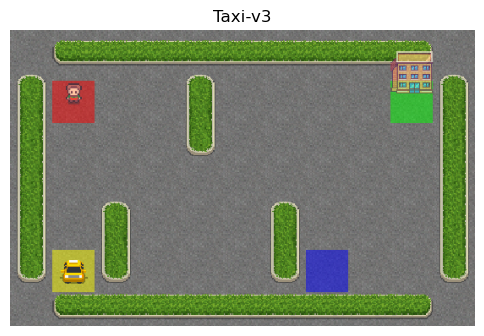

Количество состояний: 500, количество действий: 6


In [8]:
# Создаём среду Taxi-v3 с поддержкой визуализации
env = gym.make("Taxi-v3", render_mode="rgb_array")
env.reset()

img = env.render()
plt.figure(figsize=(6,5))
plt.imshow(img)
plt.title("Taxi-v3")
plt.axis('off')
plt.show()

n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"Количество состояний: {n_states}, количество действий: {n_actions}")

In [9]:
# 2. Создание стохастической политики

def initialize_policy(n_states, n_actions):
    """Возвращает равномерную политику (все действия равновероятны)."""
    policy = np.ones((n_states, n_actions)) / n_actions
    return policy

policy = initialize_policy(n_states, n_actions)

assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1./n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

In [12]:
# 3. Игра с моделью (генерация одной сессии)

def generate_session(env, policy, t_max=10**4):
    """
    Играет эпизод до конца или до t_max шагов, используя заданную политику.
    Возвращает список состояний, список действий и суммарную награду.
    """
    states, actions = [], []
    total_reward = 0.0

    # reset в gymnasium возвращает (observation, info)
    s, _ = env.reset()

    for t in range(t_max):
        a = np.random.choice(n_actions, p=policy[s])

        new_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s

        if done:
            break

    return states, actions, total_reward

s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

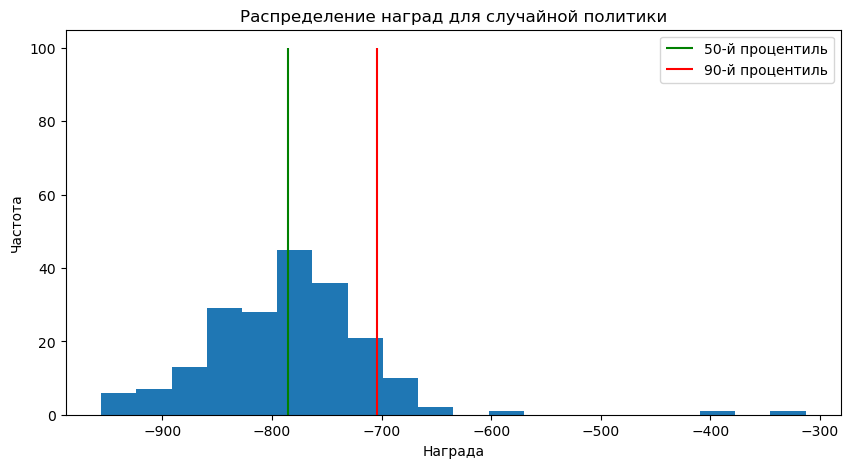

In [13]:
# 4. Cтроим распределение наград при случайной политике
sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]
plt.figure(figsize=(10,5))
plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50-й процентиль", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90-й процентиль", color='red')
plt.legend()
plt.title("Распределение наград для случайной политики")
plt.xlabel("Награда")
plt.ylabel("Частота")
plt.show()

In [14]:
# 4. Шаги кросс-энтропийного метода

def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Отбирает состояния и действия из тех сессий, чья награда >= заданного процентиля.
    Возвращает два плоских списка: elite_states и elite_actions.
    """
    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for i in range(len(rewards_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

In [15]:
states_batch = [[1,2,3], [4,2,0,2], [3,1]]
actions_batch = [[0,2,4], [3,2,0,1], [3,3]]
rewards_batch = [3,4,5]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1,2,3,4,2,0,2,3,1]) and \
       np.all(test_result_0[1] == [0,2,4,3,2,0,1,3,3]), \
       "Для процентиля 0 должны быть все состояния и действия."
assert np.all(test_result_30[0] == [4,2,0,2,3,1]) and \
       np.all(test_result_30[1] == [3,2,0,1,3,3]), \
       "Для процентиля 30 должны быть только из двух первых сессий."
assert np.all(test_result_90[0] == [3,1]) and \
       np.all(test_result_90[1] == [3,3]), \
       "Для процентиля 90 должна быть только одна сессия."
assert np.all(test_result_100[0] == [3,1]) and \
       np.all(test_result_100[1] == [3,3]), \
       "Проверьте использование >= и правильность вычисления процентиля."
print("Все тесты select_elites пройдены!")

Все тесты select_elites пройдены!


In [17]:
def get_new_policy(elite_states, elite_actions):
    """
    Строит новую политику на основе частот элитных пар (state, action).
    Для состояний, не встречавшихся в элитах, используется равномерное распределение.
    """
    from collections import defaultdict

    new_policy = np.zeros((n_states, n_actions))

    for s, a in zip(elite_states, elite_actions):
        new_policy[s, a] += 1

    for s in range(n_states):
        total = new_policy[s].sum()
        if total > 0:
            new_policy[s] /= total
        else:
            new_policy[s] = 1.0 / n_actions

    return new_policy

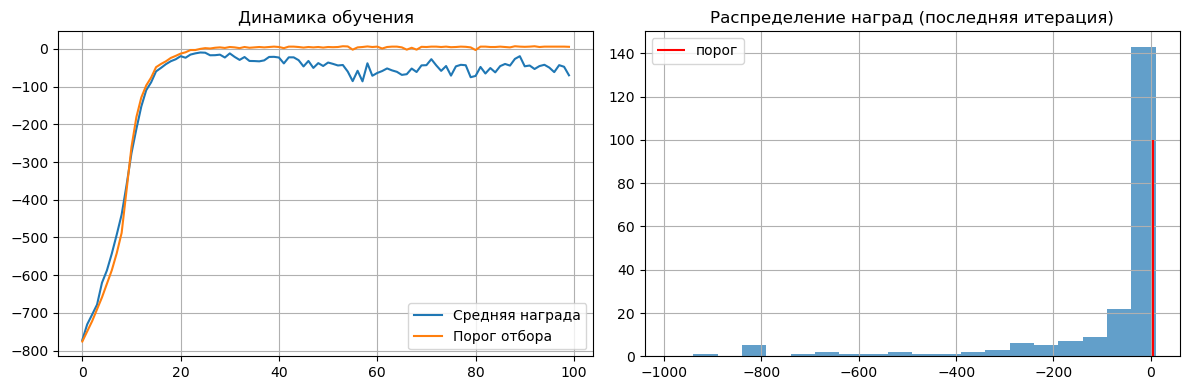

mean reward = -70.020, threshold = 5.500


In [18]:
# 5. Тренировочный цикл

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    Отображает текущий прогресс обучения: динамику средних наград и гистограмму последней итерации.
    """
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(wait=True)
    plt.figure(figsize=[12, 4])

    plt.subplot(1, 2, 1)
    plt.plot(np.array(log)[:, 0], label='Средняя награда')
    plt.plot(np.array(log)[:, 1], label='Порог отбора')
    plt.legend()
    plt.grid()
    plt.title('Динамика обучения')

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range, bins=20, alpha=0.7)
    plt.vlines([threshold], 0, 100, color='red', label='порог')
    plt.legend()
    plt.grid()
    plt.title('Распределение наград (последняя итерация)')

    plt.tight_layout()
    plt.show()
    print(f"mean reward = {mean_reward:.3f}, threshold = {threshold:.3f}")

n_sessions = 250       
percentile = 50           
learning_rate = 0.5      
log = []                 

policy = initialize_policy(n_states, n_actions)

for i in range(100):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    new_policy = get_new_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    show_progress(rewards_batch, log, percentile)

#  6. Анализ сходимости (задание №3)
 
 Из полученных графиков видно, что средняя награда быстро растёт от значений около [–800, –700] до уровня примерно [–50, 0] уже после 20–30 итераций. Затем она стабилизируется и колеблется около этого значения, иногда немного снижаясь.
 
**Причина быстрого начального роста:**  
Изначально политика случайна, поэтому большинство эпизодов заканчиваются с большим отрицательным счётом. Однако даже редкие удачные эпизоды (где такси случайно подобрало и высадило пассажира) попадают в элиту. Увеличивая вероятности действий, которые привели к этим успехам, алгоритм быстро исключает заведомо плохие действия. Пространство состояний невелико (500 состояний, 6 действий), поэтому улучшение происходит стремительно.
 
**Причина последующей стабилизации и небольших колебаний:**  
Когда большинство эпизодов становятся успешными, медиана перестаёт отражать только выдающиеся траектории. Политика подстраивается под средние результаты, а не под оптимальные. Из-за фиксированного процентиля (50%) и сглаживания (learning_rate = 0.5) алгоритм не может тонко настроиться до абсолютного оптимума. Поэтому средняя награда колеблется около –50/–100.